In [1]:
!pip install pandas numpy pyarrow

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.9 MB 5.6 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.9 MB 4.9 MB/s eta 0:00:02
   ------------ --------------------------- 3.1/9.9 MB 5.2 MB/s eta 0:00:02
   --------------- ------------------------ 3.9/9.9 MB 4.9 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.9 MB 5.5 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.9 MB 5.9 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.9 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 6.0 MB/s  0:00:01
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.4 MB 8.6 MB/s eta 0:00:02
   ---------- ----------------------------- 3.4/12.4 MB 8.5 MB/s eta 0:00:02
   ---------------- ----------------------- 5.2/12.4 MB 8.4 MB/s eta 0:00:01
   --------------------- 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Savitha132408\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from datetime import datetime
import os

# -----------------------------
# CONFIGURATION
# -----------------------------
NUM_SKUS = 1500
NUM_WAREHOUSES = 10
START_DATE = "2023-01-01"
END_DATE = "2023-12-31"
OUTPUT_FILE = "demand_sensing_1gb_with_vehicle_model.parquet"

# -----------------------------
# VEHICLE HIERARCHY
# -----------------------------
vehicle_catalog = {
    "Passenger": ["Sedan_A", "Sedan_B", "Hatch_C"],
    "SUV": ["SUV_X", "SUV_Y", "SUV_Z"],
    "Truck": ["Truck_T1", "Truck_T2"],
    "EV": ["EV_E1", "EV_E2"],
    "Hybrid": ["Hybrid_H1", "Hybrid_H2"]
}

vehicle_types = list(vehicle_catalog.keys())

# -----------------------------
# DATE RANGE
# -----------------------------
dates = pd.date_range(start=START_DATE, end=END_DATE, freq="D")

writer = None

for w in range(NUM_WAREHOUSES):
    warehouse_id = f"WH_{w+1}"
    
    for chunk_start in range(0, NUM_SKUS, 10):
        chunk_end = min(chunk_start + 10, NUM_SKUS)
        sku_ids = np.arange(chunk_start, chunk_end)
        
        rows = []
        
        for date in dates:
            day_of_year = date.dayofyear
            
            for sku in sku_ids:
                
                # Deterministic vehicle assignment
                v_type = vehicle_types[sku % len(vehicle_types)]
                model_list = vehicle_catalog[v_type]
                v_model = model_list[sku % len(model_list)]
                
                # Deterministic demand logic
                base_demand = (sku % 40) + 25
                seasonal = 12 * np.sin(day_of_year / 365 * 2 * np.pi)
                demand = int(base_demand + seasonal)
                
                shipped = int(demand * 0.94)
                backorder = demand - shipped
                
                rows.append([
                    date,
                    f"SKU_{sku}",
                    v_type,
                    v_model,
                    warehouse_id,
                    demand,
                    shipped,
                    backorder,
                    500 + (sku % 200),
                    100 + (sku % 50),
                    75,
                    25000,
                    round((sku % 100) / 100, 2),
                    int(date.month % 4 == 0),
                    round(6 + np.cos(day_of_year), 2),
                    round(3 + np.sin(day_of_year), 2),
                    int(date.weekday() == 6),
                    date.weekday() + 1,
                    date.week,
                    date.month
                ])
        
        df = pd.DataFrame(rows, columns=[
            "date", "sku_id", "vehicle_type", "vehicle_model",
            "warehouse_id", "demand_qty", "shipped_qty",
            "backorder_qty", "on_hand_inventory",
            "in_transit_inventory", "safety_stock",
            "warehouse_capacity", "labor_utilization",
            "promotion_flag", "weather_index",
            "fuel_price_index", "is_holiday",
            "day_of_week", "week_of_year", "month"
        ])
        
        table = pa.Table.from_pandas(df)
        
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_FILE, table.schema)
        
        writer.write_table(table)

writer.close()

print("1GB dataset with vehicle model generated successfully.")

1GB dataset with vehicle model generated successfully.


In [16]:
df.head()

,date,sku_id,vehicle_type,vehicle_model,warehouse_id,demand_qty,shipped_qty,backorder_qty,on_hand_inventory,in_transit_inventory,safety_stock,warehouse_capacity,labor_utilization,promotion_flag,weather_index,fuel_price_index,is_holiday,day_of_week,week_of_year,month
0,2023-01-01,SKU_1490,Passenger,Hatch_C,WH_10,35,32,3,590,140,75,25000,0.90,0,6.54,3.84,1,7,52,1
1,2023-01-01,SKU_1491,SUV,SUV_X,WH_10,36,33,3,591,141,75,25000,0.91,0,6.54,3.84,1,7,52,1
2,2023-01-01,SKU_1492,Truck,Truck_T1,WH_10,37,34,3,592,142,75,25000,0.92,0,6.54,3.84,1,7,52,1
3,2023-01-01,SKU_1493,EV,EV_E2,WH_10,38,35,3,593,143,75,25000,0.93,0,6.54,3.84,1,7,52,1
4,2023-01-01,SKU_1494,Hybrid,Hybrid_H1,WH_10,39,36,3,594,144,75,25000,0.94,0,6.54,3.84,1,7,52,1


In [17]:
df.to_csv("Data.csv", index=False)

In [31]:
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)
correlation_matrix.to_csv("correlation_matrix.csv", index=False)

                      demand_qty  shipped_qty  backorder_qty  \
demand_qty              1.000000     0.999377       0.885213   
shipped_qty             0.999377     1.000000       0.868239   
backorder_qty           0.885213     0.868239       1.000000   
on_hand_inventory       0.322891     0.320186       0.318819   
in_transit_inventory    0.322891     0.320186       0.318819   
safety_stock                 NaN          NaN            NaN   
warehouse_capacity           NaN          NaN            NaN   
labor_utilization       0.322891     0.320186       0.318819   
promotion_flag         -0.011439    -0.014506       0.030381   
weather_index          -0.000329    -0.000345      -0.000074   
fuel_price_index        0.000838     0.000793       0.001331   
is_holiday              0.001248     0.001067       0.003474   
day_of_week             0.000999     0.000870       0.002570   
week_of_year           -0.739067    -0.741553      -0.615404   
month                  -0.740017    -0.7

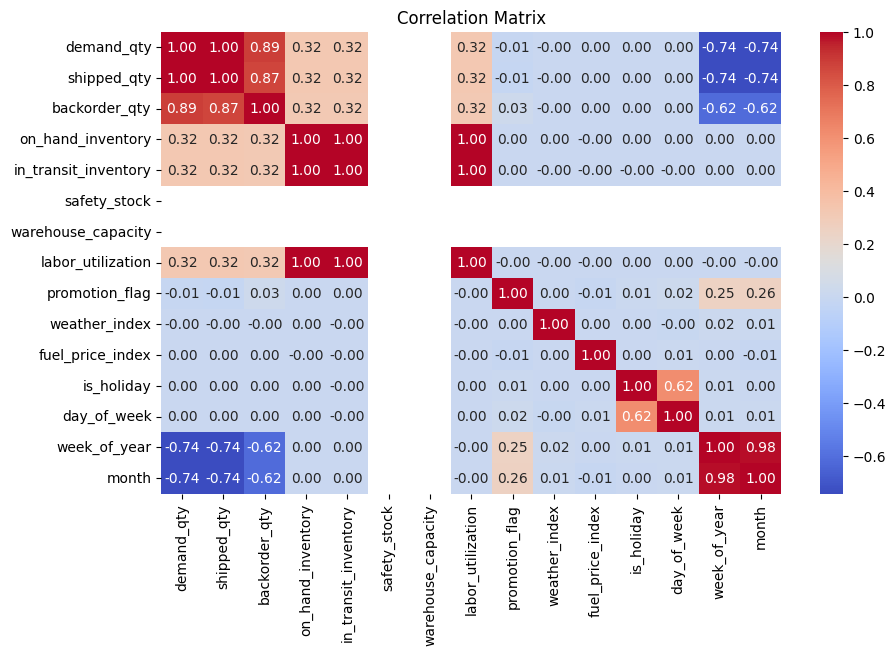

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [23]:
!pip install seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 2.5 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.3 MB 2.5 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.3 MB 2.6 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.3 MB 2.6 MB/s eta 0:00:03
   ------------- -------------------------- 2.9/8.3 MB 2.3 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.3 MB 2.3 MB/s eta 0:00:03
   ------------------- -------------------- 3.9/8.3 MB 2.4 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.3 MB 2.5 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.3 MB 2.5 MB/s eta 0:00:02
   --------------------------- ------------ 5.8/8.3 MB 2.6 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 2.6 MB/s eta 0:00:01
   -----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Savitha132408\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [28]:
sns.scatterplot(x="Feature1", y="Sales", data=df)
plt.show()

ValueError: Could not interpret value `Feature1` for `x`. An entry with this name does not appear in `data`.

In [27]:
import numpy as np

threshold = 0.8
corr_matrix = df.corr(numeric_only=True)

high_corr = np.where((corr_matrix > threshold) & (corr_matrix < 1))

for i, j in zip(*high_corr):
    print(corr_matrix.index[i], "-", corr_matrix.columns[j], ":", corr_matrix.iloc[i, j])

demand_qty - shipped_qty : 0.9993767250152898
demand_qty - backorder_qty : 0.8852125066559989
shipped_qty - demand_qty : 0.9993767250152898
shipped_qty - backorder_qty : 0.8682392084643662
backorder_qty - demand_qty : 0.8852125066559989
backorder_qty - shipped_qty : 0.8682392084643662
on_hand_inventory - in_transit_inventory : 0.9999999999999994
in_transit_inventory - on_hand_inventory : 0.9999999999999994
in_transit_inventory - labor_utilization : 0.9999999999999983
labor_utilization - in_transit_inventory : 0.9999999999999983
week_of_year - month : 0.9814409579135829
month - week_of_year : 0.9814409579135829


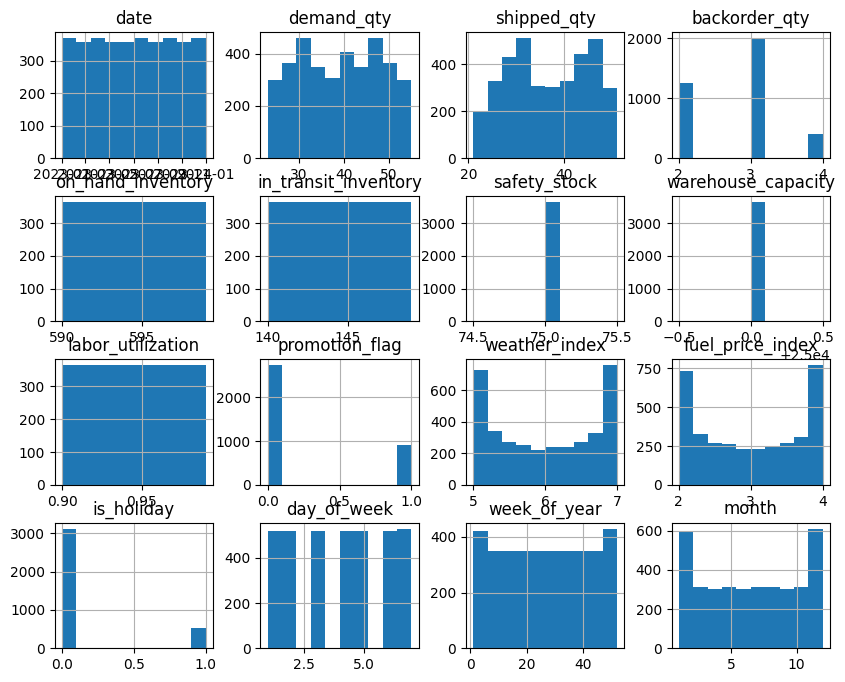

In [30]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()